In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("joker.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


In [9]:
pixel_data = img.reshape((-1, 3))
pixel_data = np.float32(pixel_data)


In [10]:
# K-Means from scratch (NumPy only) + Elbow method
import numpy as np

def kmeans_from_scratch(data, n_clusters, max_iter=100, tol=1e-4, random_state=42):
    rng = np.random.default_rng(random_state)
    n_samples = data.shape[0]

    # Pick initial centroids from existing points
    init_idx = rng.choice(n_samples, size=n_clusters, replace=False)
    centroids = data[init_idx].copy()

    for _ in range(max_iter):
        # Compute distance of each point to each centroid
        distances = np.linalg.norm(data[:, None, :] - centroids[None, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.zeros_like(centroids)
        for cluster_id in range(n_clusters):
            cluster_points = data[labels == cluster_id]

            # Handle empty cluster by reinitializing to a random point
            if cluster_points.shape[0] == 0:
                new_centroids[cluster_id] = data[rng.integers(0, n_samples)]
            else:
                new_centroids[cluster_id] = cluster_points.mean(axis=0)

        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids

        if shift < tol:
            break

    # WCSS (within-cluster sum of squares)
    wcss = 0.0
    for cluster_id in range(n_clusters):
        cluster_points = data[labels == cluster_id]
        if cluster_points.shape[0] > 0:
            diff = cluster_points - centroids[cluster_id]
            wcss += np.sum(diff ** 2)

    return centroids, labels, wcss


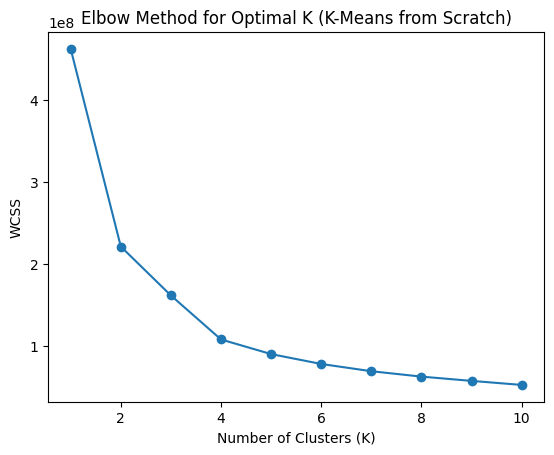

In [11]:
wcss_values = []
k_values = range(1, 11)

for k in k_values:
    _, _, inertia = kmeans_from_scratch(pixel_data, n_clusters=k, random_state=42)
    wcss_values.append(inertia)

plt.plot(k_values, wcss_values, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K (K-Means from Scratch)")
plt.show()

K=3, WCSS=161716384.00


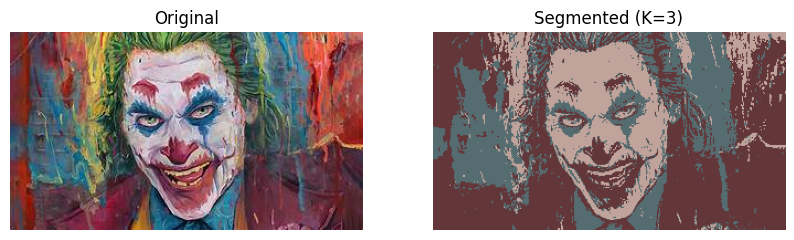

In [13]:
k = 3  # chosen from elbow method

centers, labels, inertia = kmeans_from_scratch(
    pixel_data, n_clusters=k, random_state=42
)

print(f"K={k}, WCSS={inertia:.2f}")

# Optional: reconstruct segmented image
segmented = centers[labels].reshape(img.shape).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(segmented)
plt.title(f"Segmented (K={k})")
plt.axis("off")
plt.show()